Before we touch the dataset, we define the tools and make the experiment reproducible. The roles are: * `pandas` and `numpy`: data
manipulation and numerical work. * `matplotlib` and `seaborn`: exploratory visualisation. * `scikit-learn`: splitting, imputation, scaling,
Logistic Regression and evaluation. * `xgboost`: gradient boosted tree model. * `shap`: model explainability. * `joblib`: saving trained
objects. * `streamlit`: deployment. SHAP is included in this edition because the goal is not just to predict risk, but to learn how to explain a
tree based model.

In [ ]:
import os
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
 roc_auc_score, roc_curve, confusion_matrix,
 classification_report, average_precision_score
)
from xgboost import XGBClassifier
import shap
import joblib
warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")
RANDOM_STATE = 42


The first inspection should answer: * How many rows and columns are there? * Is the first column an identifier? * What are the data types?
* Which variables are missing values? * Does the target exist only in the training data? We do not start with imputation. We first measure
the problem.

In [2]:
df = pd.read_csv("cs-training.csv", index_col=0)
test_df = pd.read_csv("cs-test.csv", index_col=0)
print("Train shape:", df.shape)
print("Test shape:", test_df.shape)

Train shape: (150000, 11)
Test shape: (101503, 11)


In [3]:
display(df.head())
df.info()

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


<class 'pandas.DataFrame'>
RangeIndex: 150000 entries, 1 to 150000
Data columns (total 11 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   SeriousDlqin2yrs                      150000 non-null  int64  
 1   RevolvingUtilizationOfUnsecuredLines  150000 non-null  float64
 2   age                                   150000 non-null  int64  
 3   NumberOfTime30-59DaysPastDueNotWorse  150000 non-null  int64  
 4   DebtRatio                             150000 non-null  float64
 5   MonthlyIncome                         120269 non-null  float64
 6   NumberOfOpenCreditLinesAndLoans       150000 non-null  int64  
 7   NumberOfTimes90DaysLate               150000 non-null  int64  
 8   NumberRealEstateLoansOrLines          150000 non-null  int64  
 9   NumberOfTime60-89DaysPastDueNotWorse  150000 non-null  int64  
 10  NumberOfDependents                    146076 non-null  float64
dtypes: float64(

In [4]:
missing = df.isnull().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)
missing_table = pd.DataFrame({
"missing_count": missing,
"missing_pct": missing_pct
})
display(missing_table)

,missing_count,missing_pct
MonthlyIncome,29731,19.82
NumberOfDependents,3924,2.62
SeriousDlqin2yrs,0,0.00
age,0,0.00
RevolvingUtilizationOfUnsecuredLines,0,0.00
DebtRatio,0,0.00
NumberOfTime30-59DaysPastDueNotWorse,0,0.00
NumberOfOpenCreditLinesAndLoans,0,0.00
NumberOfTimes90DaysLate,0,0.00
NumberRealEstateLoansOrLines,0,0.00


The missing-value audit is our diagnosis. The result shows: * `MonthlyIncome`: 29,731 missing values (19.82%). *
`NumberOfDependents`: 3,924 missing values (2.62%). * The remaining displayed variables have no missing values. We will not delete
these borrowers. Instead, we will preserve the fact that the values were missing, then impute them using rules learned from the training
data only. This is the correct next step because missing values must be resolved before any model that does not natively accept NaNs is
trained. The sequence is: **audit → create missingness flags → split → fit imputer on training → transform validation → verify zero
NaNs.**

In [5]:
df["MonthlyIncome_missing"] = (
 df["MonthlyIncome"].isnull().astype(int)
)
df["NumberOfDependents_missing"] = (
 df["NumberOfDependents"].isnull().astype(int)
)
print("Missing MonthlyIncome:")
print(
 df["MonthlyIncome_missing"]
 .value_counts()
)
print("\nMissing NumberOfDependents:")
print(
 df["NumberOfDependents_missing"]
 .value_counts()
)


Missing MonthlyIncome:
MonthlyIncome_missing
0    120269
1     29731
Name: count, dtype: int64

Missing NumberOfDependents:
NumberOfDependents_missing
0    146076
1      3924
Name: count, dtype: int64


In [6]:
# Step 2 — separate predictors and target
X = df.drop(
 columns=["SeriousDlqin2yrs"]
)
y = df["SeriousDlqin2yrs"]

In [7]:
X_train, X_valid, y_train, y_valid = train_test_split(
 X,
 y,
 test_size=0.20,
 random_state=RANDOM_STATE,
 stratify=y
)

In [8]:
# Step 4 — learn median values from TRAINING data only
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(
 strategy="median"
)
X_train_imputed = pd.DataFrame(
 imputer.fit_transform(X_train),
 columns=X_train.columns,
 index=X_train.index
)
X_valid_imputed = pd.DataFrame(
 imputer.transform(X_valid),
 columns=X_valid.columns,
 index=X_valid.index
)


In [9]:
# Step 5 — prove that the problem is fixed
print(
 "Training missing values:",
 X_train_imputed.isnull().sum().sum()
)
print(
 "Validation missing values:",
 X_valid_imputed.isnull().sum().sum()
)
assert X_train_imputed.isnull().sum().sum() == 0
assert X_valid_imputed.isnull().sum().sum() == 0
print("■ No missing values remain in the model matrices.")

Training missing values: 0
Validation missing values: 0
■ No missing values remain in the model matrices.


Now that the original missing values have been handled, we check for values that are technically present but logically suspicious. Three
important cases need attention: * `age == 0` is not a believable borrower age. * `96` and `98` appear as suspicious codes in the
late-payment variables. * Extreme ratio values need investigation because they can dominate downstream modelling. We convert the
clearly invalid/sentinel values to `NaN` so they can be handled by the same training-only imputation process. Deterministic value-code
replacement is different from learning a statistic from the full dataset.

In [10]:
# Impossible age
df.loc[df["age"] == 0, "age"] = np.nan
# Sentinel values
past_due_cols = [
 "NumberOfTime30-59DaysPastDueNotWorse",
 "NumberOfTimes90DaysLate",
 "NumberOfTime60-89DaysPastDueNotWorse"
]
for col in past_due_cols:
 print(
 col,
 "96/98 count:",
 df[col].isin([96, 98]).sum()
 )
 df[col] = df[col].replace(
 [96, 98],
 np.nan
 )
# Investigate extreme ratios
for col in [
 "RevolvingUtilizationOfUnsecuredLines",
 "DebtRatio"
]:
 print(
 f"{col} 99th percentile:",
 df[col].quantile(0.99)
 )
print(
 "Age missing after quality correction:",
    df["age"].isnull().sum()
)


NumberOfTime30-59DaysPastDueNotWorse 96/98 count: 269
NumberOfTimes90DaysLate 96/98 count: 269
NumberOfTime60-89DaysPastDueNotWorse 96/98 count: 269
RevolvingUtilizationOfUnsecuredLines 99th percentile: 1.0929557681400022
DebtRatio 99th percentile: 4979.040000000037
Age missing after quality correction: 1


### `SeriousDlqin2yrs` is the target. It is binary, so this is a classification problem. The reference project shows a strong imbalance: roughly 93% of observations are class 0 and roughly 7% are class 1. That means accuracy can look excellent even when the model misses many risky borrowers. We therefore pay attention to ROC AUC, Average Precision, precision, recall and the confusion matrix.


SeriousDlqin2yrs
0    139974
1     10026
Name: count, dtype: int64
SeriousDlqin2yrs
0    0.93316
1    0.06684
Name: proportion, dtype: float64


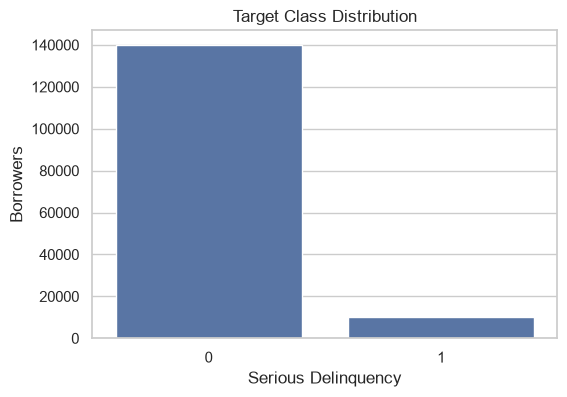

,count,mean,std,min,25%,50%,75%,max
SeriousDlqin2yrs,150000.0,0.066840,0.249746,0.0,0.000000,0.000000,0.000000,1.0
RevolvingUtilizationOfUnsecuredLines,150000.0,6.048438,249.755371,0.0,0.029867,0.154181,0.559046,50708.0
age,149999.0,52.295555,14.771298,21.0,41.000000,52.000000,63.000000,109.0
NumberOfTime30-59DaysPastDueNotWorse,149731.0,0.245794,0.697780,0.0,0.000000,0.000000,0.000000,13.0
DebtRatio,150000.0,353.005076,2037.818523,0.0,0.175074,0.366508,0.868254,329664.0
MonthlyIncome,120269.0,6670.221237,14384.674215,0.0,3400.000000,5400.000000,8249.000000,3008750.0
NumberOfOpenCreditLinesAndLoans,150000.0,8.452760,5.145951,0.0,5.000000,8.000000,11.000000,58.0
NumberOfTimes90DaysLate,149731.0,0.090456,0.485527,0.0,0.000000,0.000000,0.000000,17.0
NumberRealEstateLoansOrLines,150000.0,1.018240,1.129771,0.0,0.000000,1.000000,2.000000,54.0
NumberOfTime60-89DaysPastDueNotWorse,149731.0,0.064823,0.330073,0.0,0.000000,0.000000,0.000000,11.0


In [11]:
target_counts = df["SeriousDlqin2yrs"].value_counts()
target_props = df["SeriousDlqin2yrs"].value_counts(normalize=True)
print(target_counts)
print(target_props)
plt.figure(figsize=(6, 4))
sns.countplot(x="SeriousDlqin2yrs", data=df)
plt.title("Target Class Distribution")
plt.xlabel("Serious Delinquency")
plt.ylabel("Borrowers")
plt.show()
display(df.describe().T)


The reference guide creates five compact features: * `TotalTimesPastDue`: combined delinquency history. *
`EstimatedMonthlyDebtPayment`: puts debt ratio into income scale. * `IncomePerDependent`: income relative to dependents. *
`CreditLinesPerAge`: rough credit experience relative to age. * `IsOverutilized`: a binary warning flag. The important lesson from our earlier
error is that engineered features can create new NaNs if their source columns are missing. That is why we make the missing value
workflow explicit.

In [13]:
def add_features(data):
 data = data.copy()
 data["TotalTimesPastDue"] = (
 data["NumberOfTime30-59DaysPastDueNotWorse"]
 + data["NumberOfTime60-89DaysPastDueNotWorse"]
 + data["NumberOfTimes90DaysLate"]
 )
 data["EstimatedMonthlyDebtPayment"] = (
 data["DebtRatio"] * data["MonthlyIncome"]
 )
 data["IncomePerDependent"] = (
 data["MonthlyIncome"]
 / (data["NumberOfDependents"] + 1)
 )
 data["CreditLinesPerAge"] = (
 data["NumberOfOpenCreditLinesAndLoans"]
 / data["age"].replace(0, np.nan)
 )
 data["IsOverutilized"] = (
 data["RevolvingUtilizationOfUnsecuredLines"] > 1
 ).astype(int)
 return data
X_train_fe = add_features(X_train)
X_valid_fe = add_features(X_valid)
print( "NaNs after feature engineering — train:",
 X_train_fe.isnull().sum().sum()
)
print(
 "NaNs after feature engineering — validation:",
 X_valid_fe.isnull().sum().sum()
)
display(
 X_train_fe.isnull()
 .sum()
 .sort_values(ascending=False)
 .head(10)
)


NaNs after feature engineering — train: 74154
NaNs after feature engineering — validation: 18964


MonthlyIncome                           23675
EstimatedMonthlyDebtPayment             23675
IncomePerDependent                      23675
NumberOfDependents                       3128
CreditLinesPerAge                           1
RevolvingUtilizationOfUnsecuredLines        0
age                                         0
NumberOfTime30-59DaysPastDueNotWorse        0
DebtRatio                                   0
NumberOfTime60-89DaysPastDueNotWorse        0
dtype: int64

Because feature engineering can create missing values, we perform a final imputation step after the engineered columns exist. This
directly addresses the earlier error where `IncomePerDependent` and `EstimatedMonthlyDebtPayment` remained missing even after
base-column checks. The important rule is still the same: the imputer is fitted on training data only.


In [14]:
# Final imputation must be fitted on TRAINING data only.
final_imputer = SimpleImputer(
 strategy="median"
)
X_train_final = pd.DataFrame(
 final_imputer.fit_transform(X_train_fe),
 columns=X_train_fe.columns,
 index=X_train_fe.index
)
X_valid_final = pd.DataFrame(
 final_imputer.transform(X_valid_fe),
 columns=X_valid_fe.columns,
 index=X_valid_fe.index
)
# Final safety check before modelling
print(
 "Final train NaNs:",
 X_train_final.isnull().sum().sum()
)
print(
 "Final validation NaNs:",
 X_valid_final.isnull().sum().sum()
)
assert X_train_final.isnull().sum().sum() == 0
assert X_valid_final.isnull().sum().sum() == 0
print("■ Final model matrices contain zero NaNs.")

Final train NaNs: 0
Final validation NaNs: 0
■ Final model matrices contain zero NaNs.


Logistic Regression is our baseline. Because the variables have different scales, we standardize them. The scaler is fitted only on the
training data. We also use `class_weight="balanced"` so the minority class is not ignored simply because it is smaller.


In [15]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(
 X_train_final
)
X_valid_scaled = scaler.transform(
 X_valid_final
)
baseline_model = LogisticRegression(
 class_weight="balanced",
 random_state=RANDOM_STATE,
 max_iter=1000
)
baseline_model.fit(
 X_train_scaled,
 y_train
)
baseline_probs = (
 baseline_model
 .predict_proba(X_valid_scaled)[:, 1]
)
baseline_auc = roc_auc_score(
 y_valid,
 baseline_probs
)
baseline_ap = average_precision_score(
 y_valid,
 baseline_probs
    )
print(f"Baseline ROC AUC: {baseline_auc:.4f}")
print(f"Baseline Average Precision: {baseline_ap:.4f}")

Baseline ROC AUC: 0.8105
Baseline Average Precision: 0.3263


XGBoost is a gradient boosted tree model. Unlike Logistic Regression, tree models do not require standard scaling because they split
using thresholds. We therefore use the final unscaled, imputed feature matrix. The imbalance is handled through `scale_pos_weight`.

In [17]:
xgb_model = XGBClassifier(
 n_estimators=500,
 learning_rate=0.03,
 max_depth=5,
 subsample=0.85,
 colsample_bytree=0.85,
 objective="binary:logistic",
 eval_metric="auc",
 scale_pos_weight=(
 (y_train == 0).sum()
 / (y_train == 1).sum()
 ),
 random_state=RANDOM_STATE,
 n_jobs=-1
)
xgb_model.fit(
 X_train_final,
 y_train,
 eval_set=[(X_valid_final, y_valid)],
 verbose=False
)
xgb_probs = (
 xgb_model.predict_proba(
 X_valid_final
 )[:, 1]
)
xgb_auc = roc_auc_score(
 y_valid,
 xgb_probs
)
xgb_ap = average_precision_score(
 y_valid,
 xgb_probs
)
print(f"XGBoost ROC AUC: {xgb_auc:.4f}")
print(f"XGBoost Average Precision: {xgb_ap:.4f}")
print(
 f"Improvement over baseline: "
 f"{xgb_auc - baseline_auc:+.4f}"
)

XGBoost ROC AUC: 0.8680
XGBoost Average Precision: 0.4028
Improvement over baseline: +0.0575


A model probability is not automatically a decision. ROC AUC evaluates ranking across thresholds. The confusion matrix evaluates one
chosen threshold. Because the positive class is rare, read class 1 precision and recall carefully.


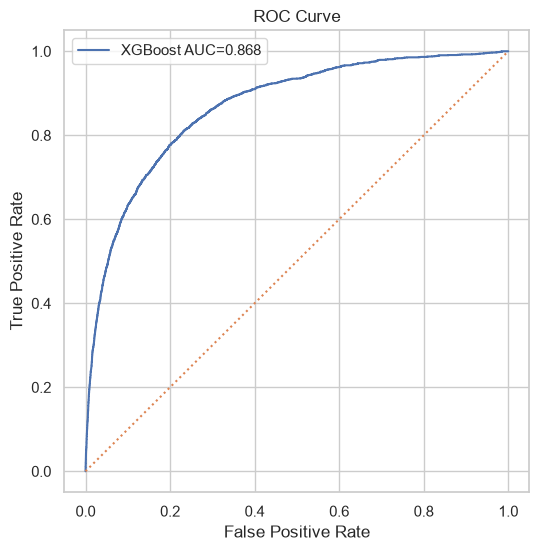

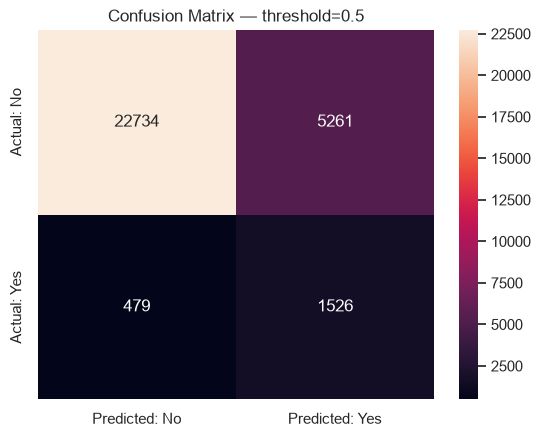

              precision    recall  f1-score   support

  No Default       0.98      0.81      0.89     27995
     Default       0.22      0.76      0.35      2005

    accuracy                           0.81     30000
   macro avg       0.60      0.79      0.62     30000
weighted avg       0.93      0.81      0.85     30000



In [19]:
fpr, tpr, thresholds = roc_curve(
 y_valid,
 xgb_probs
)
plt.figure(figsize=(6, 6))
plt.plot(
 fpr,
 tpr,
 label=f"XGBoost AUC={xgb_auc:.3f}"
)
plt.plot([0, 1], [0, 1], linestyle=":")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()
threshold = 0.50
preds = (
 xgb_probs >= threshold
).astype(int)
cm = confusion_matrix(
 y_valid,
 preds
)
sns.heatmap(
 cm,
 annot=True,
 fmt="d",
 xticklabels=["Predicted: No", "Predicted: Yes"],
     yticklabels=["Actual: No", "Actual: Yes"]
)
plt.title(f"Confusion Matrix — threshold={threshold}")
plt.show()
print(
 classification_report(
 y_valid,
 preds,
 target_names=["No Default", "Default"]
 )
)


This is where SHAP belongs. Feature importance tells us which variables matter globally. SHAP goes further: it estimates each feature's
contribution to a prediction. We use the modern `shap.Explainer` interface. The important concept is not memorizing the API. It is
understanding the question: > Which features pushed this prediction toward higher or lower risk? We explain the same XGBoost model
that we evaluated.

In [21]:
# Check what XGBoost thinks the feature types are
booster = xgb_model.get_booster()

print("Feature types:")
print(booster.feature_types)

print("\nFeature names:")
print(booster.feature_names)

Feature types:
['float', 'float', 'float', 'float', 'float', 'float', 'float', 'float', 'float', 'float', 'float', 'float', 'float', 'float', 'float', 'float', 'float']

Feature names:
['RevolvingUtilizationOfUnsecuredLines', 'age', 'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio', 'MonthlyIncome', 'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate', 'NumberRealEstateLoansOrLines', 'NumberOfTime60-89DaysPastDueNotWorse', 'NumberOfDependents', 'MonthlyIncome_missing', 'NumberOfDependents_missing', 'TotalTimesPastDue', 'EstimatedMonthlyDebtPayment', 'IncomePerDependent', 'CreditLinesPerAge', 'IsOverutilized']


In [22]:
# Check the pandas data types
print(X_train_final.dtypes)

RevolvingUtilizationOfUnsecuredLines    float64
age                                     float64
NumberOfTime30-59DaysPastDueNotWorse    float64
DebtRatio                               float64
MonthlyIncome                           float64
NumberOfOpenCreditLinesAndLoans         float64
NumberOfTimes90DaysLate                 float64
NumberRealEstateLoansOrLines            float64
NumberOfTime60-89DaysPastDueNotWorse    float64
NumberOfDependents                      float64
MonthlyIncome_missing                   float64
NumberOfDependents_missing              float64
TotalTimesPastDue                       float64
EstimatedMonthlyDebtPayment             float64
IncomePerDependent                      float64
CreditLinesPerAge                       float64
IsOverutilized                          float64
dtype: object


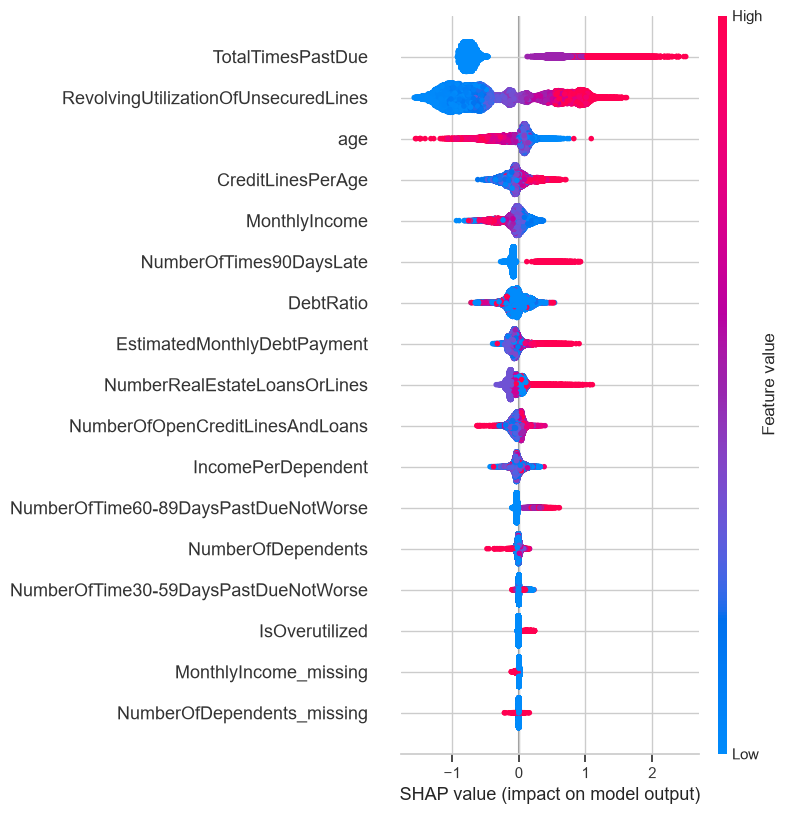

In [23]:
explainer = shap.TreeExplainer(
    xgb_model,
    feature_perturbation="tree_path_dependent"
)

shap_values = explainer.shap_values(
    X_valid_final
)

shap.summary_plot(
    shap_values,
    X_valid_final
)

Predicted probability: 0.06384691


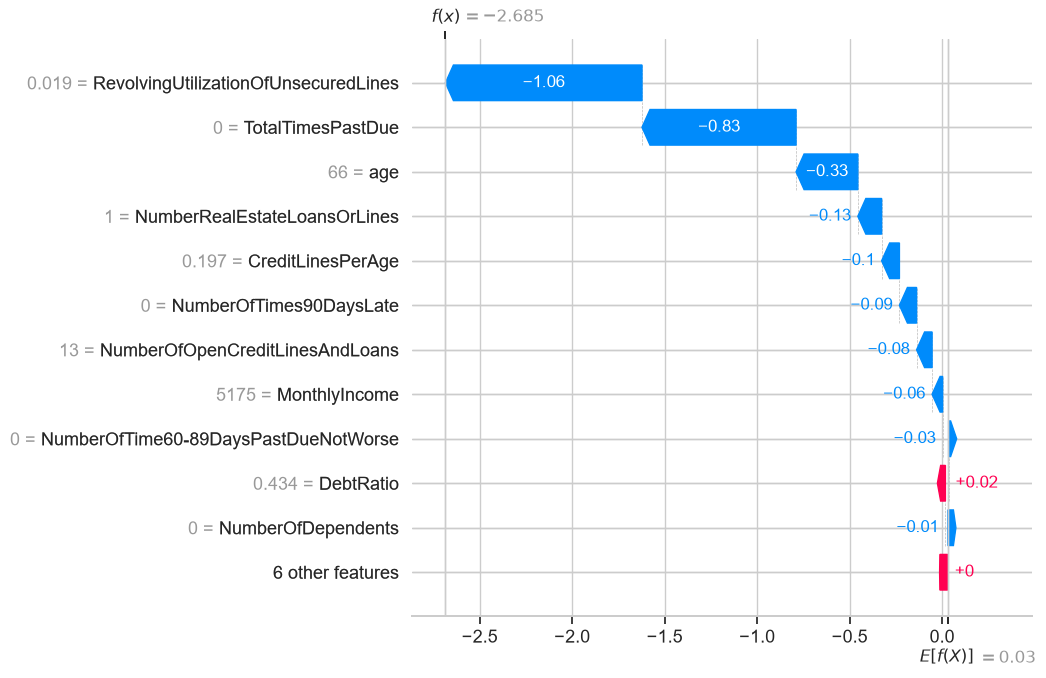

In [24]:
row_number = 0
single_row = X_valid_final.iloc[[row_number]]
single_shap = explainer(single_row)
print(
 "Predicted probability:",
 xgb_model.predict_proba(single_row)[0, 1]
)
shap.plots.waterfall(
 single_shap[0],
 max_display=12
)


Deployment bugs often happen because people save the model but forget the preprocessing. We save: * the XGBoost model, * the final
imputer, * the scaler used by Logistic Regression, * the feature order, * and the engineered feature names. For the deployed XGBoost
application, the imputer and feature order are the critical artifacts.

In [25]:
os.makedirs("model", exist_ok=True)
joblib.dump(
 xgb_model,
 "model/xgb_credit_model.pkl"
)
joblib.dump(
 final_imputer,
 "model/final_imputer.pkl"
)
joblib.dump(
 scaler,
 "model/scaler.pkl"
)
joblib.dump(
 list(X_train_fe.columns),
 "model/feature_columns.pkl"
)

print("Model artifacts saved.")

Model artifacts saved.


In [26]:
shap_background = X_train_final.sample(
    n=min(100, len(X_train_final)),
    random_state=42
)

joblib.dump(
    shap_background,
    "model/shap_background.pkl"
)

print("SHAP background saved.")

SHAP background saved.
